# **House Prices - Advanced Regression Techniques**

## **Import Libraries & Data sets**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df_test = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## **Perform Exploratory data analysis (EDA) & Data Visualization**

In [4]:
df.shape

(1460, 81)

In [5]:
df_test.shape

(1459, 80)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


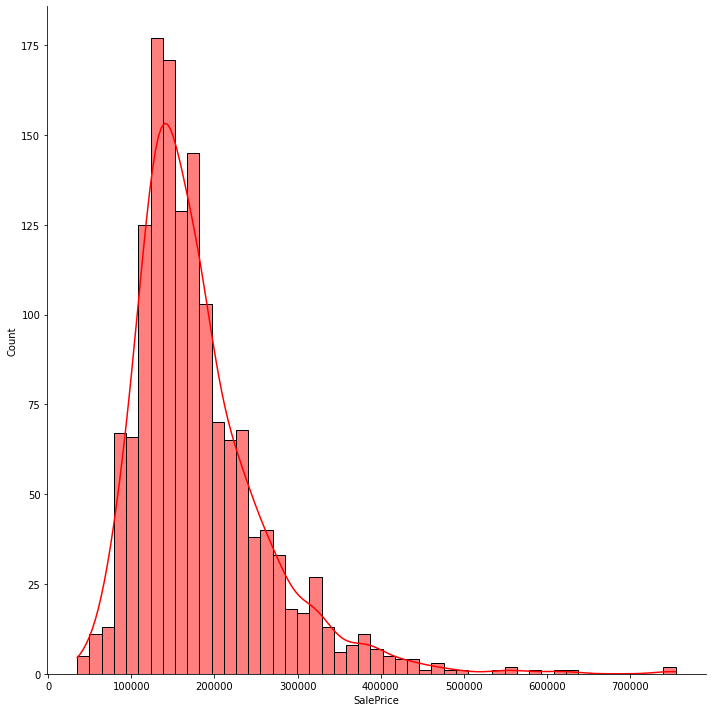

In [8]:
sns.displot(data=df, x="SalePrice", kde=True, height = 10, aspect = 1, color = 'r');

### **LotShape: General shape of property**
* Reg    Regular    
* IR1    Slightly irregular
* IR2    Moderately Irregular
* IR3    Irregular

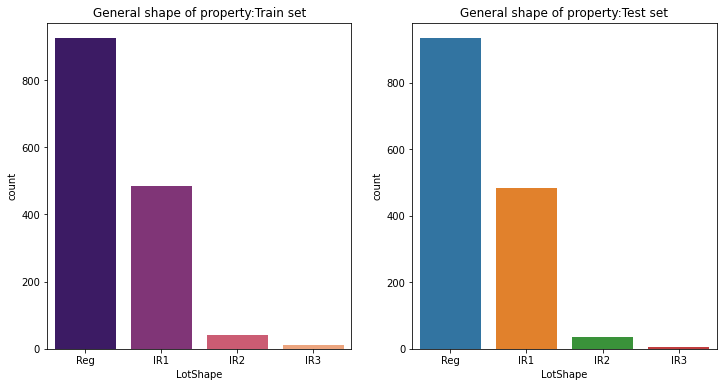

In [9]:
#define plotting region (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize = (12,6))
#create boxplot in each subplot
ax1 =sns.countplot(data = df, x = 'LotShape', ax=axes[0], palette= 'magma')
ax1.set(title = 'General shape of property:Train set') 
ax2 = sns.countplot(data = df_test, x = 'LotShape', ax=axes[1])
ax2.set(title = 'General shape of property:Test set');

### **LandContour: Flatness of the property**
* Lvl    Near Flat/Level    
* Bnk    Banked - Quick and significant rise from street grade to building
* HLS    Hillside - Significant slope from side to side
* Low    Depression

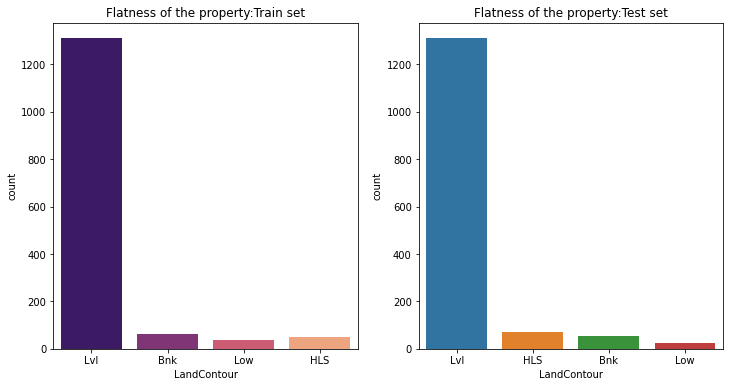

In [10]:
#define plotting region (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize = (12,6))
#create boxplot in each subplot
ax1 =sns.countplot(data = df, x = 'LandContour', ax=axes[0], palette= 'magma')
ax1.set(title = 'Flatness of the property:Train set') 
ax2 = sns.countplot(data = df_test, x = 'LandContour', ax=axes[1])
ax2.set(title = 'Flatness of the property:Test set');

### **LandSlope: Slope of property**

* Gtl    Gentle slope
* Mod    Moderate Slope    
* Sev    Severe Slope

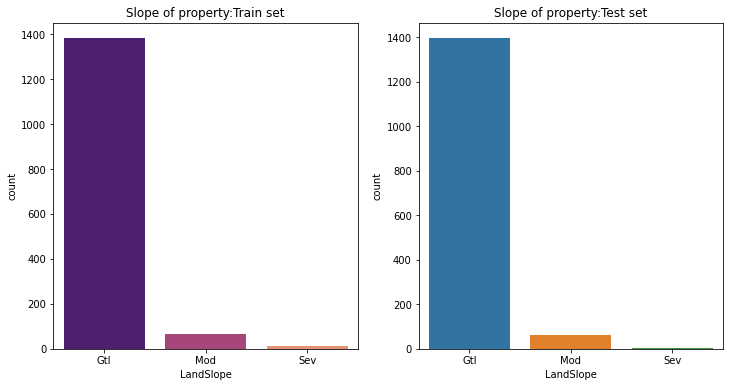

In [11]:
#define plotting region (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize = (12,6))
#create boxplot in each subplot
ax1 =sns.countplot(data = df, x = 'LandSlope', ax=axes[0], palette= 'magma')
ax1.set(title = 'Slope of property:Train set') 
ax2 = sns.countplot(data = df_test, x = 'LandSlope', ax=axes[1])
ax2.set(title = 'Slope of property:Test set');

### **LotConfig: Lot configuration**

* Inside    Inside lot
* Corner    Corner lot
* CulDSac    Cul-de-sac
* FR2    Frontage on 2 sides of property
* FR3    Frontage on 3 sides of property

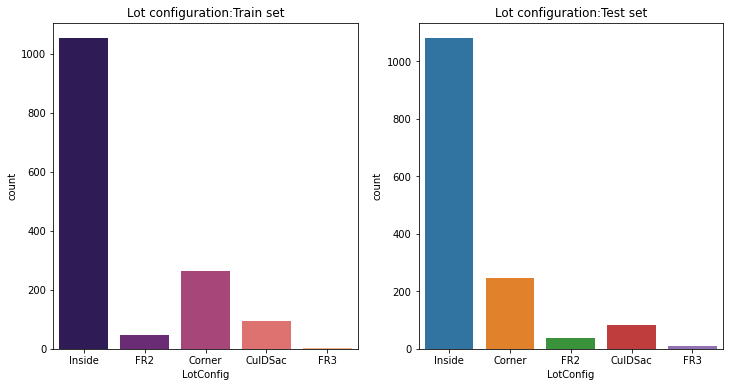

In [12]:
#define plotting region (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize = (12,6))
#create boxplot in each subplot
ax1 =sns.countplot(data = df, x = 'LotConfig', ax=axes[0], palette= 'magma')
ax1.set(title = 'Lot configuration:Train set') 
ax2 = sns.countplot(data = df_test, x = 'LotConfig', ax=axes[1])
ax2.set(title = 'Lot configuration:Test set');

### **BldgType: Type of dwelling**

*    1Fam    Single-family Detached    
*    2FmCon    Two-family Conversion; originally built as one-family dwelling
*    Duplx    Duplex
*    TwnhsE    Townhouse End Unit
*    TwnhsI    Townhouse Inside Unit

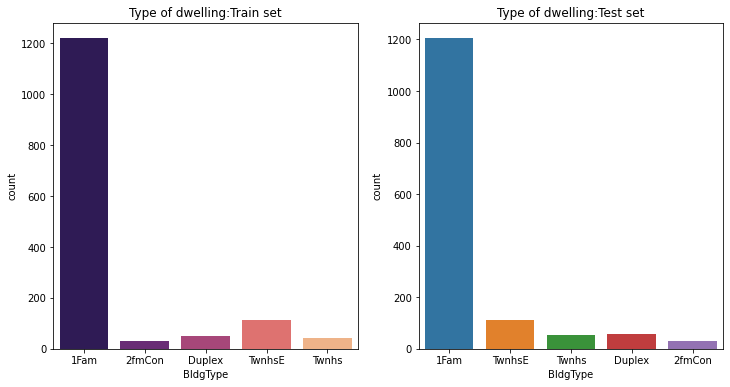

In [13]:
#define plotting region (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize = (12,6))
#create boxplot in each subplot
ax1 =sns.countplot(data = df, x = 'BldgType', ax=axes[0], palette= 'magma')
ax1.set(title = 'Type of dwelling:Train set') 
ax2 = sns.countplot(data = df_test, x = 'BldgType', ax=axes[1])
ax2.set(title = 'Type of dwelling:Test set');

### **HouseStyle: Style of dwelling**

*    1Story    One story
*    1.5Fin    One and one-half story: 2nd level finished
*    1.5Unf    One and one-half story: 2nd level unfinished
*    2Story    Two story
*    2.5Fin    Two and one-half story: 2nd level finished
*    2.5Unf    Two and one-half story: 2nd level unfinished
*    SFoyer    Split Foyer
*    SLvl    Split Level

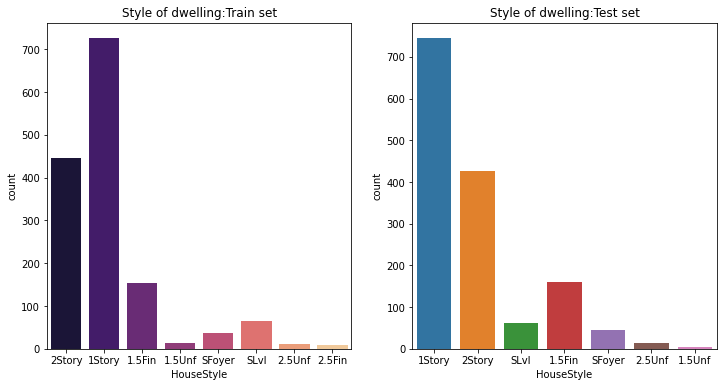

In [14]:
#define plotting region (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize = (12,6))
#create boxplot in each subplot
ax1 =sns.countplot(data = df, x = 'HouseStyle', ax=axes[0], palette= 'magma')
ax1.set(title = 'Style of dwelling:Train set') 
ax2 = sns.countplot(data = df_test, x = 'HouseStyle', ax=axes[1])
ax2.set(title = 'Style of dwelling:Test set');

### **OverallCond: Rates the overall condition of the house**

*    10    Very Excellent
*    9    Excellent
*    8    Very Good
*    7    Good
*    6    Above Average    
*    5    Average
*    4    Below Average    
*    3    Fair
*    2    Poor
*    1    Very Poor

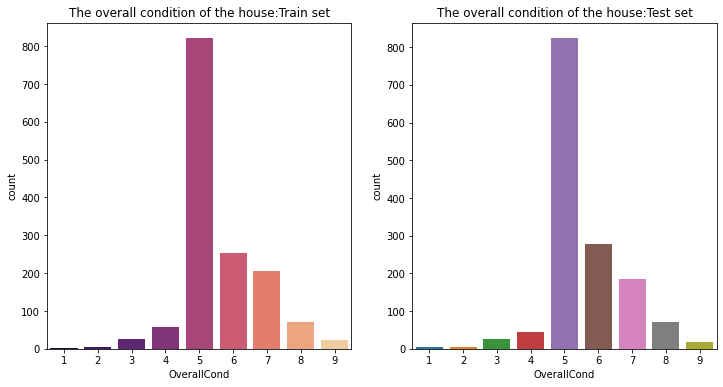

In [15]:
#define plotting region (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize = (12,6))
#create boxplot in each subplot
ax1 =sns.countplot(data = df, x = 'OverallCond', ax=axes[0], palette= 'magma')
ax1.set(title = 'The overall condition of the house:Train set') 
ax2 = sns.countplot(data = df_test, x = 'OverallCond', ax=axes[1])
ax2.set(title = 'The overall condition of the house:Test set');

In [16]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

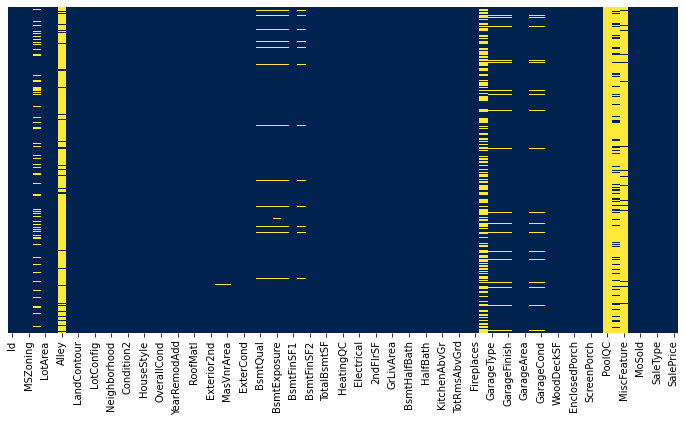

In [17]:
plt.figure(figsize = (12,6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap = 'cividis'); 

In [18]:
df_test.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

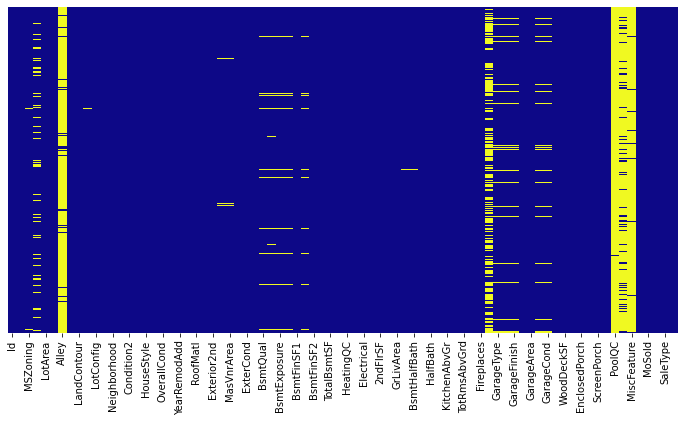

In [19]:
plt.figure(figsize = (12,6))
sns.heatmap(df_test.isnull(),yticklabels=False,cbar=False, cmap = 'plasma');

## **Working with Feature Data**

Going through data description, 'OverallQual', 'Condition2', 'Exterior2nd', 'ExterCond', 'BsmtFinType2', 'GarageQual' are duplicated. Drop those columns from both train and test sets.

In [20]:
df.drop(['OverallQual', 'Condition2', 'Exterior2nd', 'ExterCond', 'BsmtFinType2', 'BsmtFinSF2', 'GarageQual'], axis = 1, inplace = True)

In [21]:
df_test.drop(['OverallQual', 'Condition2', 'Exterior2nd', 'ExterCond', 'BsmtFinType2', 'BsmtFinSF2', 'GarageQual'], axis = 1, inplace = True)

### **Alley: Type of alley access to property**

*    Grvl    Gravel
*    Pave    Paved
*    NA     No alley access

### **Street: Type of road access to property**

*    Grvl    Gravel    
*    Pave    Paved

In [22]:
df['Alley'].value_counts()

Grvl    50
Pave    41
Name: Alley, dtype: int64

In [23]:
df['Alley'] = df['Alley'].fillna('NoAl')
df['Alley'].value_counts()

NoAl    1369
Grvl      50
Pave      41
Name: Alley, dtype: int64

In [24]:
df_test['Alley'].value_counts()

Grvl    70
Pave    37
Name: Alley, dtype: int64

In [25]:
df_test['Alley'] = df_test['Alley'].fillna('NoAl')
df_test['Alley'].value_counts()

NoAl    1352
Grvl      70
Pave      37
Name: Alley, dtype: int64

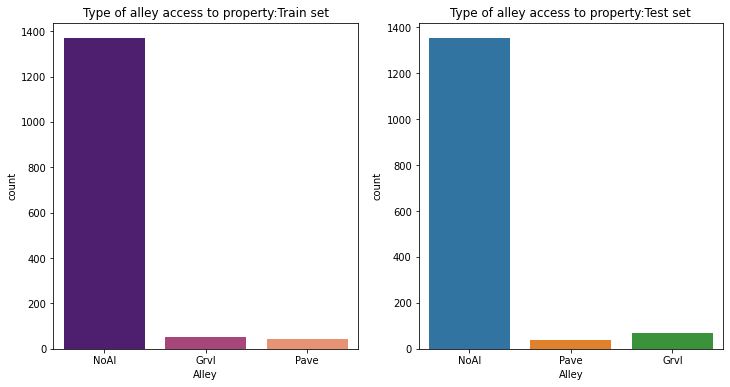

In [26]:
#define plotting region (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize = (12,6))
#create boxplot in each subplot
ax1 =sns.countplot(data = df, x = 'Alley', ax=axes[0], palette= 'magma')
ax1.set(title = 'Type of alley access to property:Train set') 
ax2 = sns.countplot(data = df_test, x = 'Alley', ax=axes[1])
ax2.set(title = 'Type of alley access to property:Test set');

### **PoolQC: Pool quality**

*    Ex    Excellent
   
*    Gd    Good
   
*    TA    Average/Typical
   
*    Fa    Fair
   
*    NA    No Pool

It perfectly matches with Pool area column

### **PoolArea: Pool area in square feet**


In [27]:
df['PoolArea'].value_counts()

0      1453
512       1
648       1
576       1
555       1
480       1
519       1
738       1
Name: PoolArea, dtype: int64

In [28]:
df['PoolQC'].unique()

array([nan, 'Ex', 'Fa', 'Gd'], dtype=object)

In [29]:
df['PoolQC'].value_counts()

Gd    3
Ex    2
Fa    2
Name: PoolQC, dtype: int64

In [30]:
df['PoolQC'] = df['PoolQC'].fillna('NP')
df['PoolQC'].value_counts()

NP    1453
Gd       3
Ex       2
Fa       2
Name: PoolQC, dtype: int64

In [31]:
df_test['PoolQC'] = df_test['PoolQC'].fillna('NP')
df_test['PoolQC'].value_counts()

NP    1456
Ex       2
Gd       1
Name: PoolQC, dtype: int64

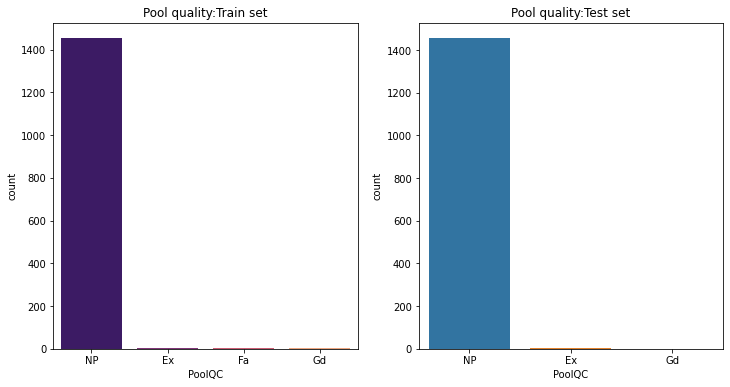

In [32]:
#define plotting region (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize = (12,6))
#create boxplot in each subplot
ax1 =sns.countplot(data = df, x = 'PoolQC', ax=axes[0], palette= 'magma')
ax1.set(title = 'Pool quality:Train set') 
ax2 = sns.countplot(data = df_test, x = 'PoolQC', ax=axes[1])
ax2.set(title = 'Pool quality:Test set');

### **MiscFeature: Miscellaneous feature not covered in other categories**

*    Elev    Elevator
*    Gar2    2nd Garage (if not described in garage section)
*    Othr    Other
*    Shed    Shed (over 100 SF)
*    TenC    Tennis Court
*    NA    None

In [33]:
df['MiscFeature'].value_counts()

Shed    49
Gar2     2
Othr     2
TenC     1
Name: MiscFeature, dtype: int64

In [34]:
df['MiscFeature'] = df['MiscFeature'].fillna('NoMF')
df['MiscFeature'].value_counts()

NoMF    1406
Shed      49
Gar2       2
Othr       2
TenC       1
Name: MiscFeature, dtype: int64

In [35]:
df_test['MiscFeature'].value_counts()

Shed    46
Gar2     3
Othr     2
Name: MiscFeature, dtype: int64

In [36]:
df_test['MiscFeature'] = df_test['MiscFeature'].fillna('NoMF')
df_test['MiscFeature'].value_counts()

NoMF    1408
Shed      46
Gar2       3
Othr       2
Name: MiscFeature, dtype: int64

### **Fence: Fence quality**

*    GdPrv    Good Privacy
*    MnPrv    Minimum Privacy
*    GdWo    Good Wood
*    MnWw    Minimum Wood/Wire
*    NA    No Fence

In [37]:
df['Fence'].value_counts()

MnPrv    157
GdPrv     59
GdWo      54
MnWw      11
Name: Fence, dtype: int64

In [38]:
df['Fence'] = df['Fence'].fillna('NoFn')
df['Fence'].value_counts()

NoFn     1179
MnPrv     157
GdPrv      59
GdWo       54
MnWw       11
Name: Fence, dtype: int64

In [39]:
df_test['Fence'].value_counts()

MnPrv    172
GdPrv     59
GdWo      58
MnWw       1
Name: Fence, dtype: int64

In [40]:
df_test['Fence'] = df_test['Fence'].fillna('NoFn')
df_test['Fence'].value_counts()

NoFn     1169
MnPrv     172
GdPrv      59
GdWo       58
MnWw        1
Name: Fence, dtype: int64

### **FireplaceQu: Fireplace quality**

*    Ex    Excellent - Exceptional Masonry Fireplace
*    Gd    Good - Masonry Fireplace in main level
*    TA    Average - Prefabricated Fireplace in main living area or Masonry Fireplace in basement
*    Fa    Fair - Prefabricated Fireplace in basement
*    Po    Poor - Ben Franklin Stove
*    NA    No Fireplace

In [41]:
df['FireplaceQu'].value_counts()

Gd    380
TA    313
Fa     33
Ex     24
Po     20
Name: FireplaceQu, dtype: int64

In [42]:
df['FireplaceQu'] = df['FireplaceQu'].fillna('NoFn')
df['FireplaceQu'].value_counts()

NoFn    690
Gd      380
TA      313
Fa       33
Ex       24
Po       20
Name: FireplaceQu, dtype: int64

In [43]:
df_test['FireplaceQu'].value_counts()

Gd    364
TA    279
Fa     41
Po     26
Ex     19
Name: FireplaceQu, dtype: int64

In [44]:
df_test['FireplaceQu'] = df_test['FireplaceQu'].fillna('NoFn')
df_test['FireplaceQu'].value_counts()

NoFn    730
Gd      364
TA      279
Fa       41
Po       26
Ex       19
Name: FireplaceQu, dtype: int64

### **MasVnrType: Masonry veneer type**

*    BrkCmn    Brick Common
*    BrkFace    Brick Face
*    CBlock    Cinder Block
*    None    None
*    Stone    Stone

In [45]:
df['MasVnrType'].value_counts()

None       864
BrkFace    445
Stone      128
BrkCmn      15
Name: MasVnrType, dtype: int64

In [46]:
df['MasVnrType'].isnull().sum()

8

In [47]:
df_test['MasVnrType'].isnull().sum()

16

In [48]:
df['MasVnrType'] = df['MasVnrType'].fillna('None')
df['MasVnrType'].value_counts()

None       872
BrkFace    445
Stone      128
BrkCmn      15
Name: MasVnrType, dtype: int64

In [49]:
df_test['MasVnrType'] = df_test['MasVnrType'].fillna('None')
df_test['MasVnrType'].value_counts()

None       894
BrkFace    434
Stone      121
BrkCmn      10
Name: MasVnrType, dtype: int64

### **MasVnrArea: Masonry veneer area in square feet**

In [50]:
df['MasVnrArea'].isnull().sum()

8

In [51]:
df['MasVnrArea'].value_counts()

0.0      861
180.0      8
72.0       8
108.0      8
120.0      7
        ... 
562.0      1
89.0       1
921.0      1
762.0      1
119.0      1
Name: MasVnrArea, Length: 327, dtype: int64

In [52]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['MasVnrArea'].value_counts()

0.0      869
180.0      8
72.0       8
108.0      8
120.0      7
        ... 
562.0      1
89.0       1
921.0      1
762.0      1
119.0      1
Name: MasVnrArea, Length: 327, dtype: int64

In [53]:
df_test['MasVnrArea'].isnull().sum()

15

In [54]:
df_test['MasVnrArea'].value_counts()

0.0       877
176.0      10
144.0       9
120.0       8
216.0       8
         ... 
647.0       1
1290.0      1
495.0       1
292.0       1
382.0       1
Name: MasVnrArea, Length: 303, dtype: int64

In [55]:
df_test['MasVnrArea'] = df_test['MasVnrArea'].fillna(0)
df_test['MasVnrArea'].value_counts()

0.0       892
176.0      10
144.0       9
120.0       8
216.0       8
         ... 
647.0       1
1290.0      1
495.0       1
292.0       1
382.0       1
Name: MasVnrArea, Length: 303, dtype: int64

### **BsmtQual: Evaluates the height of the basement**

*    Ex    Excellent (100+ inches)    
*    Gd    Good (90-99 inches)
*    TA    Typical (80-89 inches)
*    Fa    Fair (70-79 inches)
*    Po    Poor (<70 inches
*    NA    No Basement

In [56]:
df['BsmtQual'] = df['BsmtQual'].fillna('NB')
df['BsmtQual'].value_counts()

TA    649
Gd    618
Ex    121
NB     37
Fa     35
Name: BsmtQual, dtype: int64

In [57]:
df_test['BsmtQual'] = df_test['BsmtQual'].fillna('NB')
df_test['BsmtQual'].value_counts()

TA    634
Gd    591
Ex    137
Fa     53
NB     44
Name: BsmtQual, dtype: int64

### **BsmtCond: Evaluates the general condition of the basement**

*    Ex    Excellent
*    Gd    Good
*    TA    Typical - slight dampness allowed
*    Fa    Fair - dampness or some cracking or settling
*    Po    Poor - Severe cracking, settling, or wetness
*    NA    No Basement

In [58]:
df['BsmtCond'] = df['BsmtCond'].fillna('NB')
df['BsmtCond'].value_counts()

TA    1311
Gd      65
Fa      45
NB      37
Po       2
Name: BsmtCond, dtype: int64

In [59]:
df_test['BsmtCond'] = df_test['BsmtCond'].fillna('NB')
df_test['BsmtCond'].value_counts()

TA    1295
Fa      59
Gd      57
NB      45
Po       3
Name: BsmtCond, dtype: int64

### **BsmtExposure: Refers to walkout or garden level walls**

*    Gd    Good Exposure
*    Av    Average Exposure (split levels or foyers typically score average or above)    
*    Mn    Mimimum Exposure
*    No    No Exposure
*    NA    No Basement

In [60]:
df['BsmtExposure'] = df['BsmtExposure'].fillna('No')
df['BsmtExposure'].value_counts()

No    991
Av    221
Gd    134
Mn    114
Name: BsmtExposure, dtype: int64

In [61]:
df_test['BsmtExposure'].isnull().sum()

44

In [62]:
df_test['BsmtExposure'] = df_test['BsmtExposure'].fillna('No')
df_test['BsmtExposure'].value_counts()

No    995
Av    197
Gd    142
Mn    125
Name: BsmtExposure, dtype: int64

### **BsmtFinType1: Rating of basement finished area**

*    GLQ    Good Living Quarters
*    ALQ    Average Living Quarters
*    BLQ    Below Average Living Quarters    
*    Rec    Average Rec Room
*    LwQ    Low Quality
*    Unf    Unfinshed
*    NA    No Basement

In [63]:
df['BsmtFinType1'].isnull().sum()

37

In [64]:
df['BsmtFinType1'] = df['BsmtFinType1'].fillna('NOB')
df['BsmtFinType1'].value_counts()

Unf    430
GLQ    418
ALQ    220
BLQ    148
Rec    133
LwQ     74
NOB     37
Name: BsmtFinType1, dtype: int64

In [65]:
df_test['BsmtFinType1'].isnull().sum()

42

In [66]:
df_test['BsmtFinType1'].value_counts()

GLQ    431
Unf    421
ALQ    209
Rec    155
BLQ    121
LwQ     80
Name: BsmtFinType1, dtype: int64

In [67]:
df_test['BsmtFinType1'] = df_test['BsmtFinType1'].fillna('NOB')
df_test['BsmtFinType1'].value_counts()

GLQ    431
Unf    421
ALQ    209
Rec    155
BLQ    121
LwQ     80
NOB     42
Name: BsmtFinType1, dtype: int64

### **Electrical: Electrical system**

*    SBrkr    Standard Circuit Breakers & Romex
*    FuseA    Fuse Box over 60 AMP and all Romex wiring (Average)    
*    FuseF    60 AMP Fuse Box and mostly Romex wiring (Fair)
*    FuseP    60 AMP Fuse Box and mostly knob & tube wiring (poor)
*    Mix    Mixed

In [68]:
df['Electrical'].isnull().sum()

1

In [69]:
df['Electrical'].value_counts()

SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: Electrical, dtype: int64

In [70]:
df['Electrical'] = df['Electrical'].fillna('Mix')
df['Electrical'].value_counts()

SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         2
Name: Electrical, dtype: int64

In [71]:
df_test['Electrical'].isnull().sum()

0

In [72]:
df_test['Electrical'].value_counts()

SBrkr    1337
FuseA      94
FuseF      23
FuseP       5
Name: Electrical, dtype: int64

### **GarageType: Garage location**

*    2Types    More than one type of garage
*    Attchd    Attached to home
*    Basment    Basement Garage
*    BuiltIn    Built-In (Garage part of house - typically has room above garage)
*    CarPort    Car Port
*    Detchd    Detached from home
*    NA    No Garage

In [73]:
df['GarageType'].value_counts()

Attchd     870
Detchd     387
BuiltIn     88
Basment     19
CarPort      9
2Types       6
Name: GarageType, dtype: int64

In [74]:
df['GarageType'].isnull().sum()

81

In [75]:
df['GarageType'] = df['GarageType'].fillna('NoGar')
df['GarageType'].value_counts()

Attchd     870
Detchd     387
BuiltIn     88
NoGar       81
Basment     19
CarPort      9
2Types       6
Name: GarageType, dtype: int64

In [76]:
df_test['GarageType'].value_counts()

Attchd     853
Detchd     392
BuiltIn     98
Basment     17
2Types      17
CarPort      6
Name: GarageType, dtype: int64

In [77]:
df_test['GarageType'].isnull().sum()

76

In [78]:
df_test['GarageType'] = df_test['GarageType'].fillna('NoGar')
df_test['GarageType'].value_counts()

Attchd     853
Detchd     392
BuiltIn     98
NoGar       76
Basment     17
2Types      17
CarPort      6
Name: GarageType, dtype: int64

### **GarageFinish: Interior finish of the garage**

*    Fin    Finished
*    RFn    Rough Finished    
*    Unf    Unfinished
*    NA    No Garage

In [79]:
df['GarageFinish'].isnull().sum()

81

In [80]:
df['GarageFinish'].value_counts()

Unf    605
RFn    422
Fin    352
Name: GarageFinish, dtype: int64

In [81]:
df['GarageFinish'] = df['GarageFinish'].fillna('NoG')
df['GarageFinish'].value_counts()

Unf    605
RFn    422
Fin    352
NoG     81
Name: GarageFinish, dtype: int64

In [82]:
df_test['GarageFinish'].isnull().sum()

78

In [83]:
df_test['GarageFinish'].value_counts()

Unf    625
RFn    389
Fin    367
Name: GarageFinish, dtype: int64

In [84]:
df_test['GarageFinish'] = df_test['GarageFinish'].fillna('NoG')
df_test['GarageFinish'].value_counts()

Unf    625
RFn    389
Fin    367
NoG     78
Name: GarageFinish, dtype: int64

### **GarageCond: Garage condition**

*    Ex    Excellent
*    Gd    Good
*    TA    Typical/Average
*    Fa    Fair
*    Po    Poor
*    NA    No Garage

In [85]:
df['GarageCond'].isnull().sum()

81

In [86]:
df['GarageCond'].value_counts()

TA    1326
Fa      35
Gd       9
Po       7
Ex       2
Name: GarageCond, dtype: int64

In [87]:
df['GarageCond'] = df['GarageCond'].fillna('NG')
df['GarageCond'].value_counts()

TA    1326
NG      81
Fa      35
Gd       9
Po       7
Ex       2
Name: GarageCond, dtype: int64

In [88]:
df_test['GarageCond'].isnull().sum()

78

In [89]:
df_test['GarageCond'].value_counts()

TA    1328
Fa      39
Po       7
Gd       6
Ex       1
Name: GarageCond, dtype: int64

In [90]:
df_test['GarageCond'] = df_test['GarageCond'].fillna('NG')
df_test['GarageCond'].value_counts()

TA    1328
NG      78
Fa      39
Po       7
Gd       6
Ex       1
Name: GarageCond, dtype: int64

### **GarageYrBlt: Year garage was built**

Build a 'GarageAge' coumn by subtracting the 'GarageYrBlt' from the current year and replace 'GarageYrBlt' column with the new 'GarageAge' column. 

In [91]:
df['GarageYrBlt'].min()

1900.0

In [92]:
df['GarageYrBlt'].max()

2010.0

In [93]:
df_test['GarageYrBlt'].max()

2207.0

In [94]:
df_test['GarageYrBlt'].min()

1895.0

In [95]:
df_test['GarageYrBlt'].sort_values(ascending = False)

1132    2207.0
148     2010.0
42      2010.0
251     2009.0
201     2009.0
         ...  
1433       NaN
1449       NaN
1453       NaN
1454       NaN
1457       NaN
Name: GarageYrBlt, Length: 1459, dtype: float64

In [96]:
df_test['GarageYrBlt'] = df_test['GarageYrBlt'].replace(to_replace = 2207.0, value = 2011)
df_test['GarageYrBlt'].sort_values(ascending = False)

1132    2011.0
148     2010.0
42      2010.0
251     2009.0
201     2009.0
         ...  
1433       NaN
1449       NaN
1453       NaN
1454       NaN
1457       NaN
Name: GarageYrBlt, Length: 1459, dtype: float64

In [97]:
df['GarageYrBlt']

0       2003.0
1       1976.0
2       2001.0
3       1998.0
4       2000.0
         ...  
1455    1999.0
1456    1978.0
1457    1941.0
1458    1950.0
1459    1965.0
Name: GarageYrBlt, Length: 1460, dtype: float64

In [98]:
df['GarageAge']  = 2022 - df['GarageYrBlt'] 
df['GarageAge']

0       19.0
1       46.0
2       21.0
3       24.0
4       22.0
        ... 
1455    23.0
1456    44.0
1457    81.0
1458    72.0
1459    57.0
Name: GarageAge, Length: 1460, dtype: float64

In [99]:
df_test['GarageAge']  = 2022 - df_test['GarageYrBlt'] 
df_test['GarageAge']

0       61.0
1       64.0
2       25.0
3       24.0
4       30.0
        ... 
1454     NaN
1455    52.0
1456    62.0
1457     NaN
1458    29.0
Name: GarageAge, Length: 1459, dtype: float64

In [100]:
df_test['GarageAge'].sort_values()

1132    11.0
42      12.0
148     12.0
404     13.0
112     13.0
        ... 
1433     NaN
1449     NaN
1453     NaN
1454     NaN
1457     NaN
Name: GarageAge, Length: 1459, dtype: float64

In [101]:
df['GarageAge'] = df['GarageAge'].fillna(0)
df['GarageAge'].value_counts()

0.0      81
17.0     65
16.0     59
18.0     53
19.0     50
         ..
95.0      1
122.0     1
116.0     1
114.0     1
89.0      1
Name: GarageAge, Length: 98, dtype: int64

In [102]:
df_test['GarageAge'] = df_test['GarageAge'].fillna(0)
df_test['GarageAge'].value_counts()

0.0      78
17.0     77
15.0     66
16.0     56
18.0     46
         ..
104.0     1
127.0     1
90.0      1
106.0     1
103.0     1
Name: GarageAge, Length: 98, dtype: int64

Drop the 'GarageYrBlt' column from both train and test data.

In [103]:
df.drop('GarageYrBlt', axis = 1, inplace = True)

In [104]:
df_test.drop('GarageYrBlt', axis = 1, inplace = True)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

In [106]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 73 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          1459 non-null   object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  BldgType       1459 non-null   object 
 15  HouseStyle     1459 non-null   object 
 16  OverallCond    1459 non-null   int64  
 17  YearBuilt      1459 non-null   int64  
 18  YearRemo

### **MSZoning: Identifies the general zoning classification of the sale.**

*    A    Agriculture
*    C    Commercial
*    FV    Floating Village Residential
*    I    Industrial
*    RH    Residential High Density
*    RL    Residential Low Density
*    RP    Residential Low Density Park 
*    RM    Residential Medium Density

In [107]:
df_test['MSZoning'].isnull().sum()

4

In [108]:
df_test['MSZoning'].value_counts()

RL         1114
RM          242
FV           74
C (all)      15
RH           10
Name: MSZoning, dtype: int64

In [109]:
df_test['MSZoning'] = df_test['MSZoning'].fillna('U')
df_test['MSZoning'].value_counts()

RL         1114
RM          242
FV           74
C (all)      15
RH           10
U             4
Name: MSZoning, dtype: int64

### **Utilities: Type of utilities available**

*    AllPub    All public Utilities (E,G,W,& S)    
*    NoSewr    Electricity, Gas, and Water (Septic Tank)
*    NoSeWa    Electricity and Gas Only
*    ELO    Electricity only    

In [110]:
df['Utilities'].value_counts()

AllPub    1459
NoSeWa       1
Name: Utilities, dtype: int64

In [111]:
df_test['Utilities'].value_counts()

AllPub    1457
Name: Utilities, dtype: int64

In [112]:
df_test['Utilities'] = df_test['Utilities'].fillna('NoSeWa')
df_test['Utilities'].value_counts()

AllPub    1457
NoSeWa       2
Name: Utilities, dtype: int64

### **Exterior1st: Exterior covering on house**

*    AsbShng    Asbestos Shingles
*    AsphShn    Asphalt Shingles
*    BrkComm    Brick Common
*    BrkFace    Brick Face
*    CBlock    Cinder Block
*    CemntBd    Cement Board
*    HdBoard    Hard Board
*    ImStucc    Imitation Stucco
*    MetalSd    Metal Siding
*    Other    Other
*    Plywood    Plywood
*    PreCast    PreCast    
*    Stone    Stone
*    Stucco    Stucco
*    VinylSd    Vinyl Siding
*    Wd Sdng    Wood Siding
*    WdShing    Wood Shingles

In [113]:
df['Exterior1st'].value_counts()

VinylSd    515
HdBoard    222
MetalSd    220
Wd Sdng    206
Plywood    108
CemntBd     61
BrkFace     50
WdShing     26
Stucco      25
AsbShng     20
BrkComm      2
Stone        2
AsphShn      1
ImStucc      1
CBlock       1
Name: Exterior1st, dtype: int64

In [114]:
df_test['Exterior1st'].value_counts()

VinylSd    510
MetalSd    230
HdBoard    220
Wd Sdng    205
Plywood    113
CemntBd     65
BrkFace     37
WdShing     30
AsbShng     24
Stucco      18
BrkComm      4
AsphShn      1
CBlock       1
Name: Exterior1st, dtype: int64

In [115]:
df_test['Exterior1st'].isnull().sum()

1

In [116]:
df_test['Exterior1st'] = df_test['Exterior1st'].fillna('Other')
df_test['Exterior1st'].isnull().sum()

0

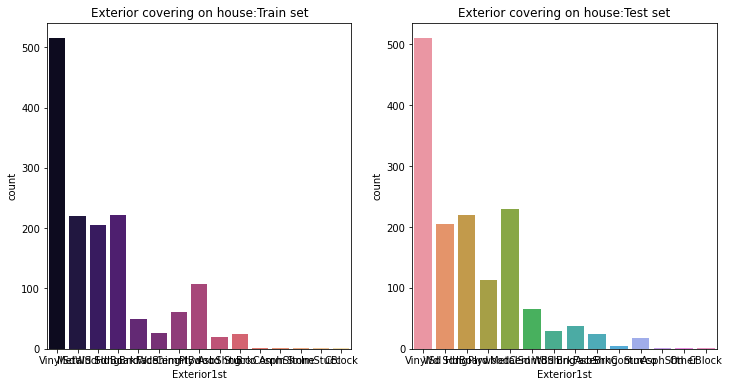

In [117]:
#define plotting region (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize = (12,6))
#create boxplot in each subplot
ax1 =sns.countplot(data = df, x = 'Exterior1st', ax=axes[0], palette= 'magma')
ax1.set(title = 'Exterior covering on house:Train set') 
ax2 = sns.countplot(data = df_test, x = 'Exterior1st', ax=axes[1])
ax2.set(title = 'Exterior covering on house:Test set');

### **BsmtFinSF1: Type 1 finished square feet**

In [118]:
df_test['BsmtFinSF1'] = df_test['BsmtFinSF1'].fillna(0)
df_test['BsmtFinSF1'].isnull().sum()

0

### **BsmtUnfSF: Unfinished square feet of basement area**

In [119]:
df_test['BsmtUnfSF'].value_counts()

0.0       123
384.0      11
624.0       8
738.0       7
100.0       7
         ... 
36.0        1
892.0       1
747.0       1
1216.0      1
1503.0      1
Name: BsmtUnfSF, Length: 793, dtype: int64

In [120]:
df_test['BsmtUnfSF'].isnull().sum()

1

In [121]:
df_test['BsmtUnfSF'].value_counts()

0.0       123
384.0      11
624.0       8
738.0       7
100.0       7
         ... 
36.0        1
892.0       1
747.0       1
1216.0      1
1503.0      1
Name: BsmtUnfSF, Length: 793, dtype: int64

In [122]:
df_test['BsmtUnfSF'] = df_test['BsmtUnfSF'].fillna(0)
df_test['BsmtUnfSF'].isnull().sum()

0

### **TotalBsmtSF: Total square feet of basement area**

In [123]:
df_test['TotalBsmtSF'] = df_test['TotalBsmtSF'].fillna(0)


### **BsmtFullBath: Basement full bathrooms**

In [124]:
df['BsmtFullBath'].value_counts()

0    856
1    588
2     15
3      1
Name: BsmtFullBath, dtype: int64

In [125]:
df_test['BsmtFullBath'].isnull().sum()

2

In [126]:
df_test['BsmtFullBath'].value_counts()

0.0    849
1.0    584
2.0     23
3.0      1
Name: BsmtFullBath, dtype: int64

In [127]:
df_test['BsmtFullBath'] = df_test['BsmtFullBath'].fillna(0)
df_test['BsmtFullBath'].isnull().sum()

0

### **BsmtHalfBath: Basement half bathrooms**

In [128]:
df['BsmtHalfBath'].value_counts()

0    1378
1      80
2       2
Name: BsmtHalfBath, dtype: int64

In [129]:
df_test['BsmtHalfBath'].isnull().sum()

2

In [130]:
df_test['BsmtHalfBath'].value_counts()

0.0    1364
1.0      91
2.0       2
Name: BsmtHalfBath, dtype: int64

In [131]:
df_test['BsmtHalfBath'] = df_test['BsmtHalfBath'].fillna(0)
df_test['BsmtHalfBath'].isnull().sum()

0

### **Functional: Home functionality (Assume typical unless deductions are warranted)**

In [132]:
df['Functional'].value_counts()

Typ     1360
Min2      34
Min1      31
Mod       15
Maj1      14
Maj2       5
Sev        1
Name: Functional, dtype: int64

In [133]:
df_test['Functional'].isnull().sum()

2

In [134]:
df_test['Functional'].value_counts()

Typ     1357
Min2      36
Min1      34
Mod       20
Maj1       5
Maj2       4
Sev        1
Name: Functional, dtype: int64

In [135]:
df_test['Functional'] = df_test['Functional'].fillna('Min1')
df_test['Functional'].isnull().sum()

0

### **GarageCars: Size of garage in car capacity**

In [136]:
df_test['GarageCars'].value_counts()

2.0    770
1.0    407
3.0    193
0.0     76
4.0     11
5.0      1
Name: GarageCars, dtype: int64

In [137]:
df_test['GarageCars'] = df_test['GarageCars'].fillna(0.0)
df_test['GarageCars'].isnull().sum()

0

### **GarageArea: Size of garage in square feet**

In [138]:
df_test['GarageArea'].value_counts()

0.0       76
576.0     50
440.0     47
484.0     34
400.0     33
          ..
453.0      1
1348.0     1
567.0      1
811.0      1
682.0      1
Name: GarageArea, Length: 459, dtype: int64

In [139]:
df_test['GarageArea'] = df_test['GarageArea'].fillna(0.0)
df_test['GarageArea'].isnull().sum()

0

### **SaleType: Type of sale**

*    WD     Warranty Deed - Conventional
*    CWD    Warranty Deed - Cash
*    VWD    Warranty Deed - VA Loan
*    New    Home just constructed and sold
*    COD    Court Officer Deed/Estate
*    Con    Contract 15% Down payment regular terms
*    ConLw    Contract Low Down payment and low interest
*    ConLI    Contract Low Interest
*    ConLD    Contract Low Down
*    Oth    Other

In [140]:
df['SaleType'].value_counts()

WD       1267
New       122
COD        43
ConLD       9
ConLI       5
ConLw       5
CWD         4
Oth         3
Con         2
Name: SaleType, dtype: int64

In [141]:
df_test['SaleType'].value_counts()

WD       1258
New       117
COD        44
ConLD      17
CWD         8
Oth         4
ConLI       4
Con         3
ConLw       3
Name: SaleType, dtype: int64

In [142]:
df_test['SaleType'] = df_test['SaleType'].fillna('Oth')
df_test['SaleType'].isnull().sum()

0

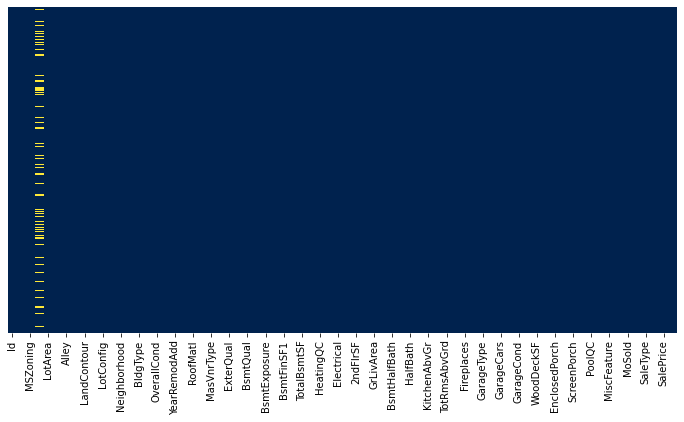

In [143]:
plt.figure(figsize = (12,6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap = 'cividis');

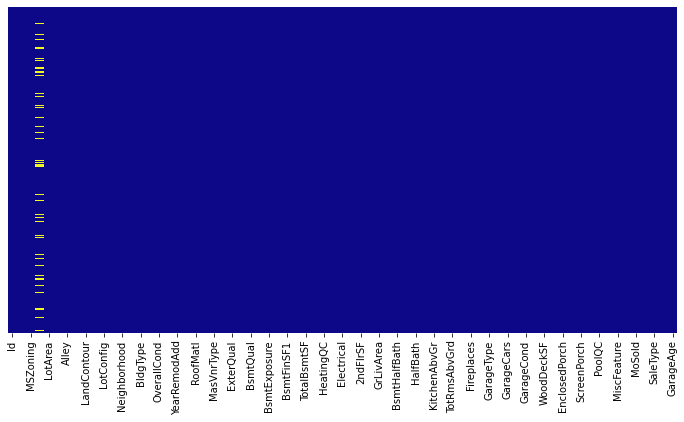

In [144]:
plt.figure(figsize = (12,6))
sns.heatmap(df_test.isnull(),yticklabels=False,cbar=False, cmap = 'plasma');

Only 'LotFrontage' is left.

### **LotFrontage: Linear feet of street connected to property**
Fill up this column with the mean value. 

In [145]:
df['LotFrontage'].value_counts()

60.0     143
70.0      70
80.0      69
50.0      57
75.0      53
        ... 
137.0      1
141.0      1
38.0       1
140.0      1
46.0       1
Name: LotFrontage, Length: 110, dtype: int64

In [146]:
df['LotFrontage'].isnull().sum()

259

In [147]:
df['LotFrontage'] = df['LotFrontage'].fillna(value=df['LotFrontage'].mean())
df['LotFrontage'].isnull().sum()

0

In [148]:
df_test['LotFrontage'].isnull().sum()

227

In [149]:
df_test['LotFrontage'] = df_test['LotFrontage'].fillna(value=df_test['LotFrontage'].mean())
df_test['LotFrontage'].isnull().sum()

0

### **KitchenQual: Kitchen quality**

*    Ex    Excellent
*    Gd    Good
*    TA    Typical/Average
*    Fa    Fair
*    Po    Poor

In [150]:
df['KitchenQual'].value_counts()

TA    735
Gd    586
Ex    100
Fa     39
Name: KitchenQual, dtype: int64

In [151]:
df_test['KitchenQual'].value_counts()

TA    757
Gd    565
Ex    105
Fa     31
Name: KitchenQual, dtype: int64

In [152]:
df_test['KitchenQual'].isnull().sum()

1

In [153]:
df_test['KitchenQual'] = df_test['KitchenQual'].fillna('TA')
df_test['KitchenQual'].isnull().sum()

0

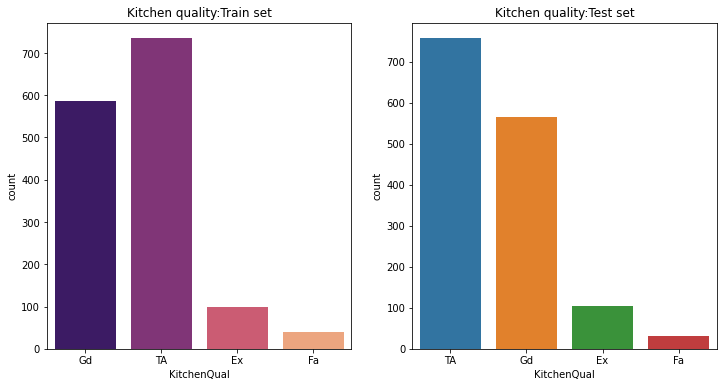

In [154]:
#define plotting region (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize = (12,6))
#create boxplot in each subplot
ax1 =sns.countplot(data = df, x = 'KitchenQual', ax=axes[0], palette= 'magma')
ax1.set(title = 'Kitchen quality:Train set') 
ax2 = sns.countplot(data = df_test, x = 'KitchenQual', ax=axes[1])
ax2.set(title = 'Kitchen quality:Test set');

In [155]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 73 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1459 non-null   object 
 3   LotFrontage    1459 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          1459 non-null   object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1459 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  BldgType       1459 non-null   object 
 15  HouseStyle     1459 non-null   object 
 16  OverallCond    1459 non-null   int64  
 17  YearBuilt      1459 non-null   int64  
 18  YearRemo

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

From the above information, it looks like 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea', in Train data are in integer format and in Test data in float format. Convert these into float format. 


In [157]:
df['BsmtFinSF1'] = df['BsmtFinSF1'].astype('float')
df['BsmtUnfSF'] = df['BsmtUnfSF'].astype('float')
df['TotalBsmtSF'] = df['TotalBsmtSF'].astype('float')
df['BsmtFullBath'] = df['BsmtFullBath'].astype('float')
df['BsmtHalfBath'] = df['BsmtHalfBath'].astype('float')
df['GarageCars'] = df['GarageCars'].astype('float')
df['GarageArea'] = df['GarageArea'].astype('float')

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

## **Further Data Visualization**

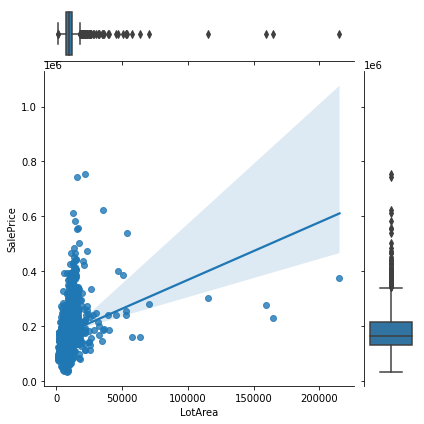

In [159]:
g = sns.JointGrid(x="LotArea", y="SalePrice", data=df)
g = g.plot(sns.regplot, sns.boxplot)

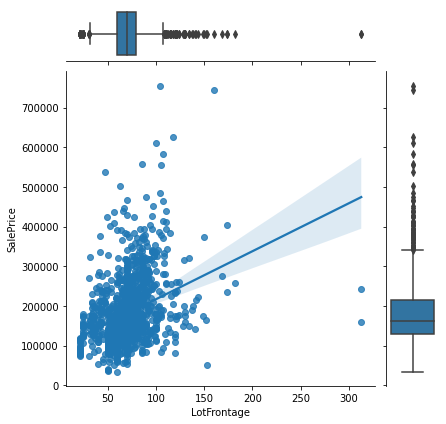

In [160]:
g = sns.JointGrid(x="LotFrontage", y="SalePrice", data=df)
g = g.plot(sns.regplot, sns.boxplot)

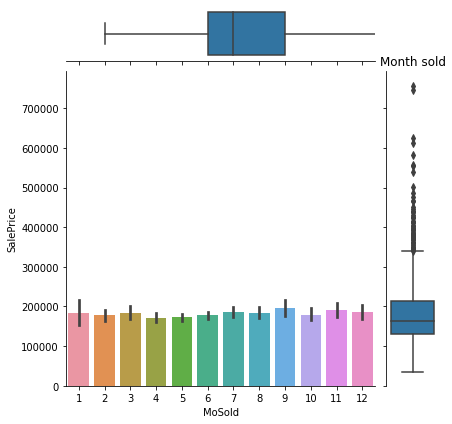

In [161]:
g = sns.JointGrid(x="MoSold", y="SalePrice", data=df)
g = g.plot(sns.barplot, sns.boxplot)
plt.title('Month sold');

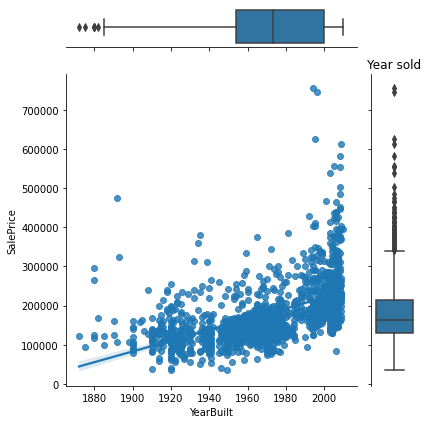

In [162]:
g = sns.JointGrid(x="YearBuilt", y="SalePrice", data=df)
g = g.plot(sns.regplot, sns.boxplot)
plt.title('Year sold')
plt.tight_layout();

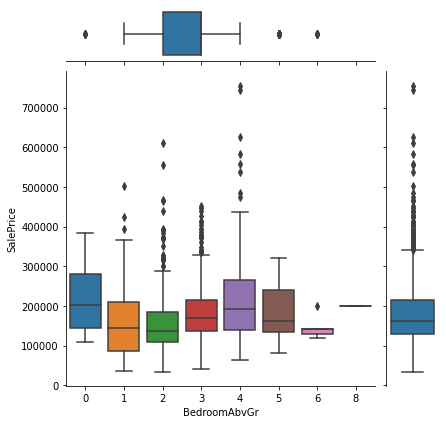

In [163]:
g = sns.JointGrid(x="BedroomAbvGr", y="SalePrice", data=df)
g = g.plot(sns.boxplot, sns.boxplot);

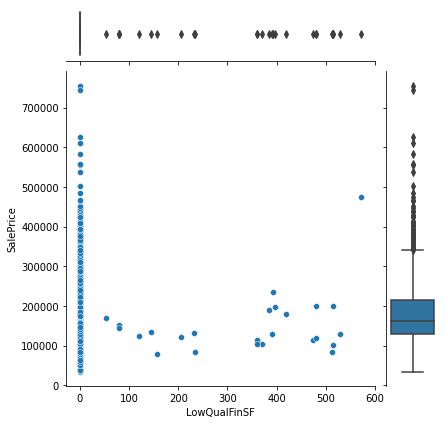

In [164]:
g = sns.JointGrid(x="LowQualFinSF", y="SalePrice", data=df)
g = g.plot(sns.scatterplot, sns.boxplot)

In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

In [166]:
MSZoning = pd.get_dummies(df['MSZoning'],drop_first=True)
PoolQC = pd.get_dummies(df['PoolQC'],drop_first=True)
Exterior1st = pd.get_dummies(df['Exterior1st'],drop_first=True)
MiscFeature = pd.get_dummies(df['MiscFeature'],drop_first=True)
HouseStyle = pd.get_dummies(df['HouseStyle'],drop_first=True)
RoofMatl = pd.get_dummies(df['RoofMatl'],drop_first=True)
Heating = pd.get_dummies(df['Heating'],drop_first=True)
Electrical = pd.get_dummies(df['Electrical'],drop_first=True)

df = pd.concat([df,MSZoning, PoolQC, Exterior1st, MiscFeature, HouseStyle, RoofMatl, Heating, Electrical],axis=1)
df.drop(['MSZoning', 'PoolQC','Exterior1st', 'MiscFeature', 'HouseStyle','RoofMatl', 'Heating', 'Electrical', 'Stone', 'ImStucc','Fa','TenC', '2.5Fin', 'Metal', 'Membran', 'Roll', 'OthW', 'Mix'],axis=1,inplace=True)
df.head()

,Id,MSSubClass,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,Tar&Grv,WdShake,WdShngl,GasA,GasW,Grav,Wall,FuseF,FuseP,SBrkr
0,1,60,65.0,8450,Pave,NoAl,Reg,Lvl,AllPub,Inside,...,0,0,0,1,0,0,0,0,0,1
1,2,20,80.0,9600,Pave,NoAl,Reg,Lvl,AllPub,FR2,...,0,0,0,1,0,0,0,0,0,1
2,3,60,68.0,11250,Pave,NoAl,IR1,Lvl,AllPub,Inside,...,0,0,0,1,0,0,0,0,0,1
3,4,70,60.0,9550,Pave,NoAl,IR1,Lvl,AllPub,Corner,...,0,0,0,1,0,0,0,0,0,1
4,5,60,84.0,14260,Pave,NoAl,IR1,Lvl,AllPub,FR2,...,0,0,0,1,0,0,0,0,0,1


In [167]:

Street = pd.get_dummies(df['Street'],drop_first=True)
Alley = pd.get_dummies(df['Alley'],drop_first=True)
LotShape = pd.get_dummies(df['LotShape'],drop_first=True)
LandContour = pd.get_dummies(df['LandContour'],drop_first=True)
Utilities = pd.get_dummies(df['Utilities'],drop_first=True)
LotConfig = pd.get_dummies(df['LotConfig'],drop_first=True)
LandSlope = pd.get_dummies(df['LandSlope'],drop_first=True)
Neighborhood = pd.get_dummies(df['Neighborhood'],drop_first=True)
Condition1 = pd.get_dummies(df['Condition1'],drop_first=True)
BldgType = pd.get_dummies(df['BldgType'],drop_first=True)

RoofStyle = pd.get_dummies(df['RoofStyle'],drop_first=True)


MasVnrType = pd.get_dummies(df['MasVnrType'],drop_first=True)
ExterQual = pd.get_dummies(df['ExterQual'],drop_first=True)
Foundation = pd.get_dummies(df['Foundation'],drop_first=True)
BsmtQual = pd.get_dummies(df['BsmtQual'],drop_first=True)
BsmtCond = pd.get_dummies(df['BsmtCond'],drop_first=True)
BsmtExposure = pd.get_dummies(df['BsmtExposure'],drop_first=True)
BsmtFinType1 = pd.get_dummies(df['BsmtFinType1'],drop_first=True)

HeatingQC = pd.get_dummies(df['HeatingQC'],drop_first=True)
CentralAir = pd.get_dummies(df['CentralAir'],drop_first=True)

KitchenQual = pd.get_dummies(df['KitchenQual'],drop_first=True)
Functional = pd.get_dummies(df['Functional'],drop_first=True)
FireplaceQu = pd.get_dummies(df['FireplaceQu'],drop_first=True)
GarageType = pd.get_dummies(df['GarageType'],drop_first=True)
GarageFinish = pd.get_dummies(df['GarageFinish'],drop_first=True)
GarageCond = pd.get_dummies(df['GarageCond'],drop_first=True)
PavedDrive = pd.get_dummies(df['PavedDrive'],drop_first=True)

Fence = pd.get_dummies(df['Fence'],drop_first=True)

SaleType = pd.get_dummies(df['SaleType'],drop_first=True)
SaleCondition = pd.get_dummies(df['SaleCondition'],drop_first=True)

df = pd.concat([df,Street, Alley, LotShape, LandContour, Utilities, LotConfig, LandSlope, Neighborhood, Condition1, BldgType, RoofStyle, MasVnrType, ExterQual, Foundation, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, HeatingQC, CentralAir, KitchenQual, Functional, FireplaceQu, GarageType, GarageFinish, GarageCond, PavedDrive, Fence, SaleType, SaleCondition],axis=1)
df.drop(['Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'BldgType', 'RoofStyle', 'MasVnrType', 'ExterQual', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'HeatingQC', 'CentralAir', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageCond', 'PavedDrive', 'Fence', 'SaleType', 'SaleCondition', 'CompShg','GasA' ],axis=1,inplace=True)
df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,...,ConLI,ConLw,New,Oth,WD,AdjLand,Alloca,Family,Normal,Partial
0,1,60,65.0,8450,5,2003,2003,196.0,706.0,150.0,...,0,0,0,0,1,0,0,0,1,0
1,2,20,80.0,9600,8,1976,1976,0.0,978.0,284.0,...,0,0,0,0,1,0,0,0,1,0
2,3,60,68.0,11250,5,2001,2002,162.0,486.0,434.0,...,0,0,0,0,1,0,0,0,1,0
3,4,70,60.0,9550,5,1915,1970,0.0,216.0,540.0,...,0,0,0,0,1,0,0,0,0,0
4,5,60,84.0,14260,5,2000,2000,350.0,655.0,490.0,...,0,0,0,0,1,0,0,0,1,0


In [168]:
MSZoning = pd.get_dummies(df_test['MSZoning'],drop_first=True)
PoolQC = pd.get_dummies(df_test['PoolQC'],drop_first=True)
Exterior1st = pd.get_dummies(df_test['Exterior1st'],drop_first=True)
MiscFeature = pd.get_dummies(df_test['MiscFeature'],drop_first=True)
HouseStyle = pd.get_dummies(df_test['HouseStyle'],drop_first=True)
RoofMatl = pd.get_dummies(df_test['RoofMatl'],drop_first=True)
Heating = pd.get_dummies(df_test['Heating'],drop_first=True)
Electrical = pd.get_dummies(df_test['Electrical'],drop_first=True)
df_test = pd.concat([df_test,MSZoning,PoolQC, Exterior1st, MiscFeature, HouseStyle, RoofMatl, Heating, Electrical],axis=1)
df_test.drop(['MSZoning','PoolQC', 'Exterior1st', 'MiscFeature','HouseStyle', 'RoofMatl', 'Heating','Electrical', 'U','Other'],axis=1,inplace=True)

In [169]:

Street = pd.get_dummies(df_test['Street'],drop_first=True)
Alley = pd.get_dummies(df_test['Alley'],drop_first=True)
LotShape = pd.get_dummies(df_test['LotShape'],drop_first=True)
LandContour = pd.get_dummies(df_test['LandContour'],drop_first=True)
Utilities = pd.get_dummies(df_test['Utilities'],drop_first=True)
LotConfig = pd.get_dummies(df_test['LotConfig'],drop_first=True)
LandSlope = pd.get_dummies(df_test['LandSlope'],drop_first=True)
Neighborhood = pd.get_dummies(df_test['Neighborhood'],drop_first=True)
Condition1 = pd.get_dummies(df_test['Condition1'],drop_first=True)
BldgType = pd.get_dummies(df_test['BldgType'],drop_first=True)

RoofStyle = pd.get_dummies(df_test['RoofStyle'],drop_first=True)


MasVnrType = pd.get_dummies(df_test['MasVnrType'],drop_first=True)
ExterQual = pd.get_dummies(df_test['ExterQual'],drop_first=True)
Foundation = pd.get_dummies(df_test['Foundation'],drop_first=True)
BsmtQual = pd.get_dummies(df_test['BsmtQual'],drop_first=True)
BsmtCond = pd.get_dummies(df_test['BsmtCond'],drop_first=True)
BsmtExposure = pd.get_dummies(df_test['BsmtExposure'],drop_first=True)
BsmtFinType1 = pd.get_dummies(df_test['BsmtFinType1'],drop_first=True)

HeatingQC = pd.get_dummies(df_test['HeatingQC'],drop_first=True)
CentralAir = pd.get_dummies(df_test['CentralAir'],drop_first=True)

KitchenQual = pd.get_dummies(df_test['KitchenQual'],drop_first=True)
Functional = pd.get_dummies(df_test['Functional'],drop_first=True)
FireplaceQu = pd.get_dummies(df_test['FireplaceQu'],drop_first=True)
GarageType = pd.get_dummies(df_test['GarageType'],drop_first=True)
GarageFinish = pd.get_dummies(df_test['GarageFinish'],drop_first=True)
GarageCond = pd.get_dummies(df_test['GarageCond'],drop_first=True)
PavedDrive = pd.get_dummies(df_test['PavedDrive'],drop_first=True)

Fence = pd.get_dummies(df_test['Fence'],drop_first=True)

SaleType = pd.get_dummies(df_test['SaleType'],drop_first=True)
SaleCondition = pd.get_dummies(df_test['SaleCondition'],drop_first=True)
df_test = pd.concat([df_test, Street, Alley, LotShape, LandContour, Utilities, LotConfig, LandSlope, Neighborhood, Condition1, BldgType, RoofStyle, MasVnrType, ExterQual, Foundation, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, HeatingQC, CentralAir, KitchenQual, Functional, FireplaceQu, GarageType, GarageFinish, GarageCond, PavedDrive, Fence, SaleType, SaleCondition],axis=1)
df_test.drop(['Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'BldgType', 'RoofStyle', 'MasVnrType', 'ExterQual', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'HeatingQC', 'CentralAir', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageCond', 'PavedDrive', 'Fence', 'SaleType', 'SaleCondition'],axis=1,inplace=True)
df_test.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,...,ConLI,ConLw,New,Oth,WD,AdjLand,Alloca,Family,Normal,Partial
0,1461,20,80.0,11622,6,1961,1961,0.0,468.0,270.0,...,0,0,0,0,1,0,0,0,1,0
1,1462,20,81.0,14267,6,1958,1958,108.0,923.0,406.0,...,0,0,0,0,1,0,0,0,1,0
2,1463,60,74.0,13830,5,1997,1998,0.0,791.0,137.0,...,0,0,0,0,1,0,0,0,1,0
3,1464,60,78.0,9978,6,1998,1998,20.0,602.0,324.0,...,0,0,0,0,1,0,0,0,1,0
4,1465,120,43.0,5005,5,1992,1992,0.0,263.0,1017.0,...,0,0,0,0,1,0,0,0,1,0


In [170]:
df.columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF',
       ...
       'ConLI', 'ConLw', 'New', 'Oth', 'WD', 'AdjLand', 'Alloca', 'Family',
       'Normal', 'Partial'],
      dtype='object', length=209)

In [171]:
my_list = list(df)
my_list

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice',
 'GarageAge',
 'FV',
 'RH',
 'RL',
 'RM',
 'Gd',
 'NP',
 'AsphShn',
 'BrkComm',
 'BrkFace',
 'CBlock',
 'CemntBd',
 'HdBoard',
 'MetalSd',
 'Plywood',
 'Stucco',
 'VinylSd',
 'Wd Sdng',
 'WdShing',
 'NoMF',
 'Othr',
 'Shed',
 '1.5Unf',
 '1Story',
 '2.5Unf',
 '2Story',
 'SFoyer',
 'SLvl',
 'Tar&Grv',
 'WdShake',
 'WdShngl',
 'GasW',
 'Grav',
 'Wall',
 'FuseF',
 'FuseP',
 'SBrkr',
 'Pave',
 'NoAl',
 'Pave',
 'IR2',
 'IR3',
 'Reg',
 'HLS',
 'Low',
 'Lvl',
 'NoSeWa',
 'CulDSac',
 'FR2',
 '

In [172]:
my_list = list(df_test)
my_list

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'GarageAge',
 'FV',
 'RH',
 'RL',
 'RM',
 'Gd',
 'NP',
 'AsphShn',
 'BrkComm',
 'BrkFace',
 'CBlock',
 'CemntBd',
 'HdBoard',
 'MetalSd',
 'Plywood',
 'Stucco',
 'VinylSd',
 'Wd Sdng',
 'WdShing',
 'NoMF',
 'Othr',
 'Shed',
 '1.5Unf',
 '1Story',
 '2.5Unf',
 '2Story',
 'SFoyer',
 'SLvl',
 'Tar&Grv',
 'WdShake',
 'WdShngl',
 'GasW',
 'Grav',
 'Wall',
 'FuseF',
 'FuseP',
 'SBrkr',
 'Pave',
 'NoAl',
 'Pave',
 'IR2',
 'IR3',
 'Reg',
 'HLS',
 'Low',
 'Lvl',
 'NoSeWa',
 'CulDSac',
 'FR2',
 'FR3',
 'Inside

In [173]:
df.isnull().sum()

Id             0
MSSubClass     0
LotFrontage    0
LotArea        0
OverallCond    0
              ..
AdjLand        0
Alloca         0
Family         0
Normal         0
Partial        0
Length: 209, dtype: int64

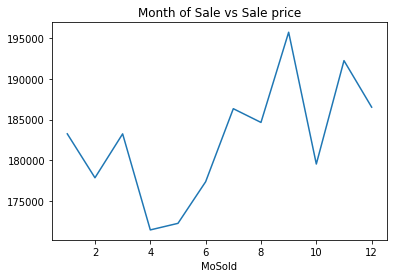

In [174]:
df.groupby('MoSold').mean()['SalePrice'].plot()
plt.title('Month of Sale vs Sale price');

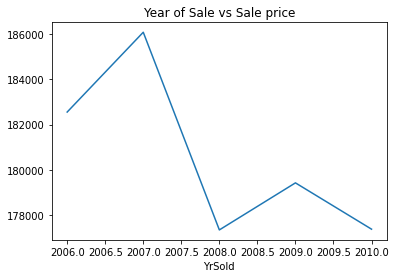

In [175]:
df.groupby('YrSold').mean()['SalePrice'].plot()
plt.title('Year of Sale vs Sale price');

## **Building the Regression Model**

### **Prepare the Data before Training**

In [176]:
X = df.drop(['Id','SalePrice'],axis=1)
y = df['SalePrice']

### **Scaling and Train Test Split**

In [177]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=101)

#Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train.shape)
print(X_test.shape)

(1022, 207)
(438, 207)


### **Creating Artificial Neural Network (ANN) Regression  Model**

In [178]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()
# input layer
model.add(Dense(104, input_dim = 207,  activation='relu'))
model.add(Dropout(0.2))
# hidden layer
model.add(Dense(104,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(20,activation='relu'))
# output layer
model.add(Dense(1))
# Compile model
model.compile(optimizer='rmsprop',loss='mse')
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 104)               21632     
_________________________________________________________________
dropout (Dropout)            (None, 104)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 104)               10920     
_________________________________________________________________
dropout_1 (Dropout)          (None, 104)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 20)                2100      
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 21        
Total params: 34,673
Trainable params: 34,673
Non-trainable params: 0
____________________________________________________

2022-03-08 22:55:24.268782: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


### **Training the Model**

In [179]:
model.fit(x=X_train,y=y_train.values,
          validation_data=(X_test,y_test.values),
          batch_size=128,epochs=400)

2022-03-08 22:55:25.759630: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/400
8/8 [==============================] - 1s 33ms/step - loss: 39292223488.0000 - val_loss: 38445674496.0000
Epoch 2/400
8/8 [==============================] - 0s 9ms/step - loss: 39289585664.0000 - val_loss: 38441824256.0000
Epoch 3/400
8/8 [==============================] - 0s 9ms/step - loss: 39283961856.0000 - val_loss: 38434369536.0000
Epoch 4/400
8/8 [==============================] - 0s 9ms/step - loss: 39273840640.0000 - val_loss: 38421872640.0000
Epoch 5/400
8/8 [==============================] - 0s 10ms/step - loss: 39257112576.0000 - val_loss: 38402580480.0000
Epoch 6/400
8/8 [==============================] - 0s 9ms/step - loss: 39232122880.0000 - val_loss: 38375784448.0000
Epoch 7/400
8/8 [==============================] - 0s 9ms/step - loss: 39199457280.0000 - val_loss: 38340288512.0000
Epoch 8/400
8/8 [==============================] - 0s 9ms/step - loss: 39155896320.0000 - val_loss: 38294253568.0000
Epoch 9/400
8/8 [==============================] - 0s 9ms/step

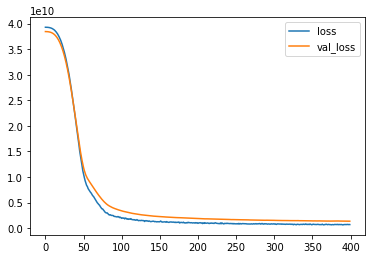

In [180]:
losses = pd.DataFrame(model.history.history)
losses.plot();

### **Deploy the model to make Predictions**

In [181]:
predictions = model.predict(X_test)

### **Evaluation on Validation Data**

In [182]:
k = X_test.shape[1]
k
n = len(X_test)
n

from sklearn import metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,explained_variance_score, r2_score
print('Mean Absolute Error(MAE):', metrics.mean_absolute_error(y_test, predictions))
print('Mean Squared Error(MSE):', metrics.mean_squared_error(y_test, predictions))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('Explained Variance Score (EVS):',explained_variance_score(y_test,predictions))
print('R2:',metrics.r2_score(y_test, predictions))
print('R2 rounded:',(metrics.r2_score(y_test, predictions)).round(2))
r2 = r2_score(y_test, predictions)
r2_rounded = r2_score(y_test, predictions).round(2)
adjusted_r2 = (1- (1-r2)*(n-1)/(n-k-1)).round(3)
print('Adjusted_r2: ', (1- (1-r2)*(n-1)/(n-k-1)).round(3))

Mean Absolute Error(MAE): 22276.352294921875
Mean Squared Error(MSE): 1345569187.321873
Root Mean Squared Error (RMSE): 36682.00086311914
Explained Variance Score (EVS): 0.7897478207057922
R2: 0.7861743276372027
R2 rounded: 0.79
Adjusted_r2:  0.594


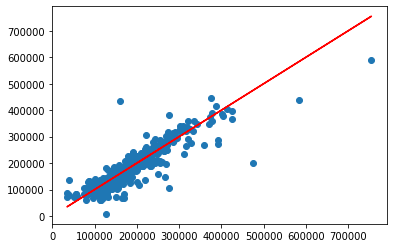

In [183]:
# Final predictions
plt.scatter(y_test,predictions)

# Perfect predictions
plt.plot(y_test,y_test,'r');

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


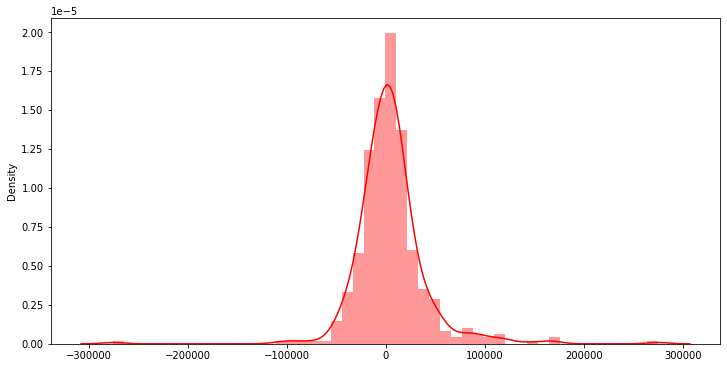

In [184]:
errors = y_test.values.reshape(438, 1) - predictions
plt.figure(figsize = (12,6))
sns.distplot(errors, color = 'red');
#sns.displot(data=df, x="SalePrice", kde=True, height = 10, aspect = 1, color = 'r');

## **Creating XG Boost Regession Model**

In [185]:
# Train an XGBoost regressor model 
import xgboost as xgb
model = xgb.XGBRegressor(objective ='reg:squarederror', learning_rate = 0.1, max_depth = 5, n_estimators = 100)
model.fit(X_train, y_train)

# predict the score of the trained model using the testing dataset
result = model.score(X_test, y_test)
print("Accuracy : {}".format(result))

Accuracy : 0.86800703811979


In [186]:
# make predictions on the test data
predictions = model.predict(X_test)
k = X_test.shape[1]
k
n = len(X_test)
n

from sklearn import metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,explained_variance_score, r2_score
print('Mean Absolute Error(MAE):', metrics.mean_absolute_error(y_test, predictions))
print('Mean Squared Error(MSE):', metrics.mean_squared_error(y_test, predictions))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('Explained Variance Score (EVS):',explained_variance_score(y_test,predictions))
print('R2:',metrics.r2_score(y_test, predictions))
print('R2 rounded:',(metrics.r2_score(y_test, predictions)).round(2))
r2 = r2_score(y_test, predictions)
r2_rounded = r2_score(y_test, predictions).round(2)
adjusted_r2 = (1- (1-r2)*(n-1)/(n-k-1)).round(3)
print('Adjusted_r2: ', (1- (1-r2)*(n-1)/(n-k-1)).round(3))

Mean Absolute Error(MAE): 16532.893764269407
Mean Squared Error(MSE): 830609629.2685483
Root Mean Squared Error (RMSE): 28820.298910117992
Explained Variance Score (EVS): 0.8693783904371829
R2: 0.86800703811979
R2 rounded: 0.87
Adjusted_r2:  0.749


## **Training without Scaling**

In [187]:
X = df.drop(['Id','SalePrice'],axis=1)
y = df['SalePrice']
X = np.array(X).astype('float32')
y = np.array(y).astype('float32')
y = y.reshape(-1,1)
y.shape


(1460, 1)

In [188]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=101)

#Scaling
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X_train= scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)
print(X_train.shape)
print(X_test.shape)

(1022, 207)
(438, 207)


In [189]:
# Train an XGBoost regressor model 
import xgboost as xgb
model = xgb.XGBRegressor(objective ='reg:squarederror', learning_rate = 0.1, max_depth = 5, n_estimators = 100)
model.fit(X_train, y_train)

# predict the score of the trained model using the testing dataset
result = model.score(X_test, y_test)
print("Accuracy : {}".format(result))

Accuracy : 0.8680205025279988


In [190]:
# make predictions on the test data
predictions = model.predict(X_test)
k = X_test.shape[1]
k
n = len(X_test)
n

from sklearn import metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,explained_variance_score, r2_score
print('Mean Absolute Error(MAE):', metrics.mean_absolute_error(y_test, predictions))
print('Mean Squared Error(MSE):', metrics.mean_squared_error(y_test, predictions))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('Explained Variance Score (EVS):',explained_variance_score(y_test,predictions))
print('R2:',metrics.r2_score(y_test, predictions))
print('R2 rounded:',(metrics.r2_score(y_test, predictions)).round(2))
r2 = r2_score(y_test, predictions)
r2_rounded = r2_score(y_test, predictions).round(2)
adjusted_r2 = (1- (1-r2)*(n-1)/(n-k-1)).round(3)
print('Adjusted_r2: ', (1- (1-r2)*(n-1)/(n-k-1)).round(3))

Mean Absolute Error(MAE): 16523.258
Mean Squared Error(MSE): 830524900.0
Root Mean Squared Error (RMSE): 28818.83
Explained Variance Score (EVS): 0.8693751096725464
R2: 0.8680205025279988
R2 rounded: 0.87
Adjusted_r2:  0.749


### **Lowering learning rate**

In [191]:
# Train an XGBoost regressor model 
import xgboost as xgb
model = xgb.XGBRegressor(objective ='reg:squarederror', learning_rate = 0.01, max_depth = 5, n_estimators = 100)
model.fit(X_train, y_train)

# predict the score of the trained model using the testing dataset
result = model.score(X_test, y_test)
print("Accuracy : {}".format(result))

Accuracy : -0.11722360459960646


In [192]:
# make predictions on the test data
predictions = model.predict(X_test)
k = X_test.shape[1]
k
n = len(X_test)
n

from sklearn import metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,explained_variance_score, r2_score
print('Mean Absolute Error(MAE):', metrics.mean_absolute_error(y_test, predictions))
print('Mean Squared Error(MSE):', metrics.mean_squared_error(y_test, predictions))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('Explained Variance Score (EVS):',explained_variance_score(y_test,predictions))
print('R2:',metrics.r2_score(y_test, predictions))
print('R2 rounded:',(metrics.r2_score(y_test, predictions)).round(2))
r2 = r2_score(y_test, predictions)
r2_rounded = r2_score(y_test, predictions).round(2)
adjusted_r2 = (1- (1-r2)*(n-1)/(n-k-1)).round(3)
print('Adjusted_r2: ', (1- (1-r2)*(n-1)/(n-k-1)).round(3))

Mean Absolute Error(MAE): 69728.91
Mean Squared Error(MSE): 7030501000.0
Root Mean Squared Error (RMSE): 83848.086
Explained Variance Score (EVS): 0.6401535272598267
R2: -0.11722360459960646
R2 rounded: -0.12
Adjusted_r2:  -1.123


### **Retrain the XGBoost algorithm with large number of estimators (n_estimators = 500)** 

In [193]:
# Train an XGBoost regressor model 
import xgboost as xgb
model = xgb.XGBRegressor(objective ='reg:squarederror', learning_rate = 0.1, max_depth = 5, n_estimators = 500)
model.fit(X_train, y_train)

# predict the score of the trained model using the testing dataset
result = model.score(X_test, y_test)
print("Accuracy : {}".format(result))

Accuracy : 0.8725561329906002


In [194]:
# make predictions on the test data
predictions = model.predict(X_test)
k = X_test.shape[1]
k
n = len(X_test)
n

from sklearn import metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,explained_variance_score, r2_score
print('Mean Absolute Error(MAE):', metrics.mean_absolute_error(y_test, predictions))
print('Mean Squared Error(MSE):', metrics.mean_squared_error(y_test, predictions))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('Explained Variance Score (EVS):',explained_variance_score(y_test,predictions))
print('R2:',metrics.r2_score(y_test, predictions))
print('R2 rounded:',(metrics.r2_score(y_test, predictions)).round(2))
r2 = r2_score(y_test, predictions)
r2_rounded = r2_score(y_test, predictions).round(2)
adjusted_r2 = (1- (1-r2)*(n-1)/(n-k-1)).round(3)
print('Adjusted_r2: ', (1- (1-r2)*(n-1)/(n-k-1)).round(3))

Mean Absolute Error(MAE): 16103.859
Mean Squared Error(MSE): 801983040.0
Root Mean Squared Error (RMSE): 28319.305
Explained Variance Score (EVS): 0.873819887638092
R2: 0.8725561329906002
R2 rounded: 0.87
Adjusted_r2:  0.758


### **Predicting on Brand New Data**

In [195]:
df_sub = df_test.drop('Id',axis=1)
#df_sub = scaler.transform(df_sub)
df_sub = np.array(df_sub).astype('float32')
print(df_sub.shape)

(1459, 207)


In [196]:
predictions = model.predict(df_sub)

## **Final Output of Prediction**

In [197]:
submission_preds = predictions.reshape(1459,)
test_ids = df_test['Id']
df = pd.DataFrame({'Id': test_ids.values, 'SalePrice': submission_preds})
df.to_csv('submission.csv', index = False)